# 02c - Data analysis

**Aim:** describe the training and benchmarking datasets independently through their sequence lengths, SP composition, taxonomy, and cleavage-site motifs.

We use the representative sequences and metadata prepared in 02b, keeping their saved split and fold assignments.

**Materials**
- `02c-DataAnalysis-2026.pdf` (slides 6–12)
- `Plotting in Seaborn.pdf` (Import libraries, Setting the theme, Distribution plots, Categorical plots, Other plots and Showing and saving figures)
- [WebLogo manual](https://weblogo.threeplusone.com/manual.html) (local installation and command-line options)


## 0. Load the prepared datasets

We load both classes' metadata and the positive sequences needed to study SPs. The `split` column identifies training and benchmarking proteins.


### 0.1 Imports and paths

We use pandas DataFrames with Seaborn and Matplotlib, following the plotting examples. Paths are relative to `notebooks/`.

We save each figure as a PDF in `results/figures/02c/`, following Showing and saving figures in `Plotting in Seaborn.pdf`. Each plot has a distinct filename; rerunning its cell updates that file while keeping the figure visible here. PDF preserves vector graphics for later use in the report.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
input_dir = Path("../data/prepared")

figure_dir = Path("../results/figures/02c")
figure_dir.mkdir(parents=True, exist_ok=True)


### 0.2 Load the metadata

We retain the original columns, including `cleavage_pos` for positives and `has_tm_in_90` for negatives. We read `cv_fold` as a nullable integer because benchmarking proteins have no fold assignment.


In [2]:
positive_metadata = pd.read_csv(
    input_dir / "positive_dataset.tsv", sep="\t", dtype={"cv_fold": "Int64"}
)
negative_metadata = pd.read_csv(
    input_dir / "negative_dataset.tsv", sep="\t", dtype={"cv_fold": "Int64"}
)


### 0.3 Load the positive sequences

We reuse the FASTA reader from 02b to keep full sequences in a dictionary keyed by `accession`, matching the positive metadata.


In [3]:
def read_fasta(fasta_path):
    sequences = {}
    with open(fasta_path, encoding="utf-8") as fasta_in:
        for line in fasta_in:
            line = line.strip()
            if line.startswith(">"):
                accession = line[1:].split()[0]
                sequences[accession] = ""
            elif line:
                sequences[accession] += line
    return sequences


In [4]:
positive_sequences = read_fasta(input_dir / "positive_dataset.fasta")


## 1. Length distributions

We describe training and benchmarking separately (02c slides 6 and 12). We compare histograms, boxplots and violin plots (slide 7) before choosing the final figures. The code follows the Distribution plots and Categorical plots sections of `Plotting in Seaborn.pdf`.

We combine the two classes only for plotting, keeping their saved splits. All figures use linear axes with shared scales between panels. We first show the full protein-length range, then apply the visualization cutoff described below. We also retain the full SP-length histogram before applying a separate SP-length cutoff.


In [5]:
protein_lengths = pd.concat([
    positive_metadata[["length", "split"]].assign(protein_class="Positive"),
    negative_metadata[["length", "split"]].assign(protein_class="Negative"),
], ignore_index=True)

sp_lengths = positive_metadata[["cleavage_pos", "split"]]

split_order = ["training", "benchmarking"]
class_order = ["Positive", "Negative"]
class_palette = {"Positive": "C0", "Negative": "C1"}

protein_bin_width = 100
protein_bins = list(range(
    0, int(protein_lengths["length"].max()) + protein_bin_width,
    protein_bin_width
))
sp_bins = [
    position - 0.5
    for position in range(
        int(sp_lengths["cleavage_pos"].min()),
        int(sp_lengths["cleavage_pos"].max()) + 2
    )
]


### 1.1 Protein lengths


#### 1.1.1 Full-range histogram

Following the Seaborn Distribution plots example, we use `displot(kind="hist")`. We use common 100-residue intervals to compare the distributions. Each class is normalized separately within each split, so the larger negative set does not dominate the comparison. Unfilled contours keep overlapping distributions visible.


Plot saved in: ../results/figures/02c/1_1_1_protein_length_histogram_full.pdf


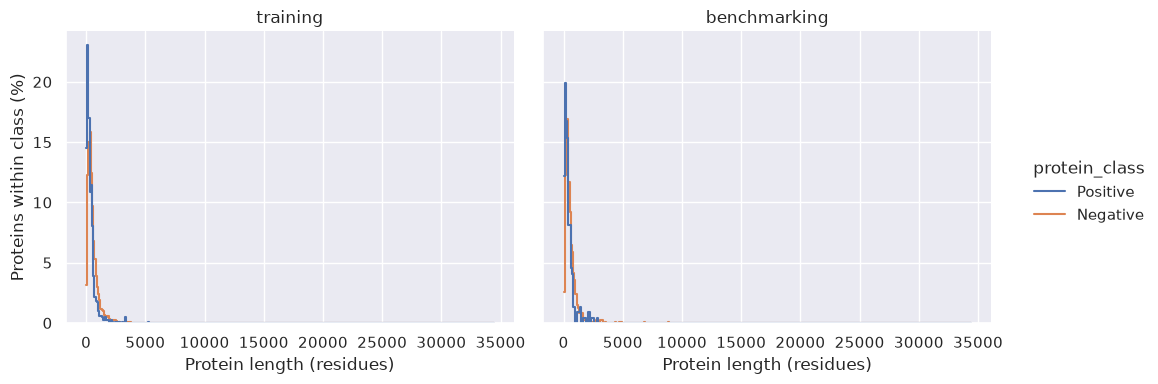

In [6]:
g = sns.displot(
    data=protein_lengths, x="length", hue="protein_class",
    hue_order=class_order, palette=class_palette,
    col="split", col_order=split_order,
    kind="hist", bins=protein_bins,
    stat="percent", common_norm=False,
    element="step", fill=False,
    height=4, aspect=1.3
)
g.set_axis_labels("Protein length (residues)", "Proteins within class (%)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_1_1_protein_length_histogram_full.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_1_1_protein_length_histogram_full.pdf")
plt.show()


#### 1.1.2 Focus on the central length range

The longest proteins compress the main distribution in the full-range histogram. We keep that plot as a reference and exclude lengths above the training set's 99th percentile from the following protein-length plots, using both classes together to define one threshold. Applying the same threshold to both classes and splits keeps the comparison consistent without choosing a separate cutoff from benchmarking.

This is our visualization choice, not a filtering requirement in 02c slides 6, 7 and 12. The prepared datasets remain unchanged. We keep linear axes and the Seaborn `displot`/`catplot` approach from the plotting support. The table reports exclusions; the cutoff need not remove exactly 1% from each group. Histogram percentages now refer to retained proteins within each class and split.


In [7]:
protein_length_cutoff = protein_lengths.loc[
    protein_lengths["split"] == "training", "length"
].quantile(0.99)

protein_lengths_trimmed = protein_lengths[
    protein_lengths["length"] <= protein_length_cutoff
]
trimmed_protein_bins = list(range(
    0, int(protein_length_cutoff) + protein_bin_width, protein_bin_width
))

print("Protein-length cutoff (residues):", protein_length_cutoff)
excluded_counts = (
    protein_lengths.assign(excluded=protein_lengths["length"] > protein_length_cutoff)
    .groupby(["split", "protein_class"])["excluded"]
    .agg(total="size", excluded="sum")
)
excluded_counts


Protein-length cutoff (residues): 2558.4000000000015


total  excluded
split        protein_class                 
benchmarking Negative        1817        22
             Positive         221         2
training     Negative        7265        74
             Positive         881         8

Plot saved in: ../results/figures/02c/1_1_2_protein_length_histogram_p99.pdf


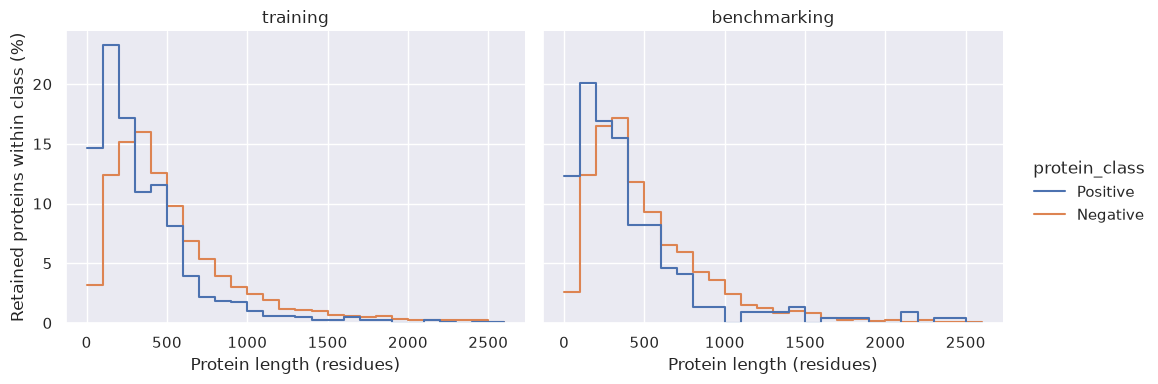

In [8]:
g = sns.displot(
    data=protein_lengths_trimmed, x="length", hue="protein_class",
    hue_order=class_order, palette=class_palette,
    col="split", col_order=split_order,
    kind="hist", bins=trimmed_protein_bins,
    stat="percent", common_norm=False,
    element="step", fill=False,
    height=4, aspect=1.3
)
g.set_axis_labels("Protein length (residues)", "Retained proteins within class (%)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_1_2_protein_length_histogram_p99.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_1_2_protein_length_histogram_p99.pdf")
plt.show()


#### 1.1.3 Boxplot

Boxplots summarize medians and interquartile ranges (02c slide 7). We use `kind="box"` within the `catplot` family introduced in the Seaborn Categorical plots section. We use the same retained proteins as in section 1.1.2. Points beyond the whiskers within this subset remain visible.


Plot saved in: ../results/figures/02c/1_1_3_protein_length_boxplot_p99.pdf


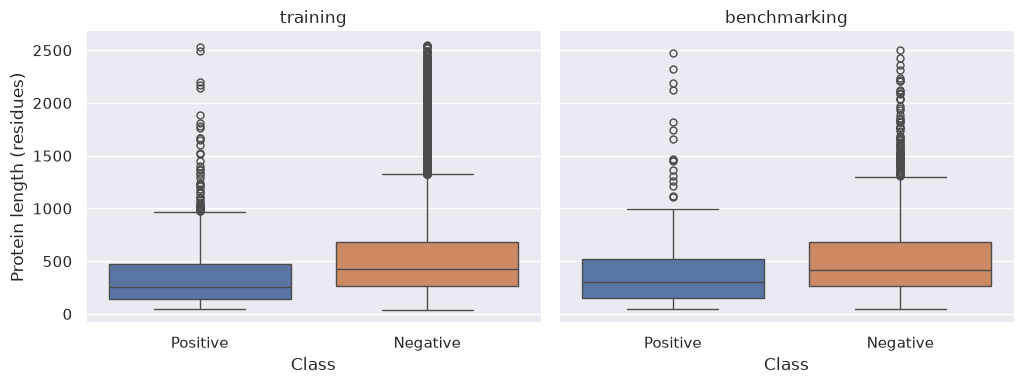

In [9]:
g = sns.catplot(
    data=protein_lengths_trimmed, x="protein_class", y="length",
    order=class_order, hue="protein_class",
    hue_order=class_order, palette=class_palette, legend=False,
    col="split", col_order=split_order,
    kind="box", height=4, aspect=1.3
)
g.set_axis_labels("Class", "Protein length (residues)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_1_3_protein_length_boxplot_p99.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_1_3_protein_length_boxplot_p99.pdf")
plt.show()


#### 1.1.4 Violin plot

We use the same retained proteins as in section 1.1.2. Following the Seaborn `catplot(kind="violin")` example, we show a smoothed distribution with an inner box summary. We keep the default smoothing and set `cut=0` to stop the curves at the observed limits. Equal-area normalization makes width describe density rather than class abundance; the outline depends on smoothing.


Plot saved in: ../results/figures/02c/1_1_4_protein_length_violin_p99.pdf


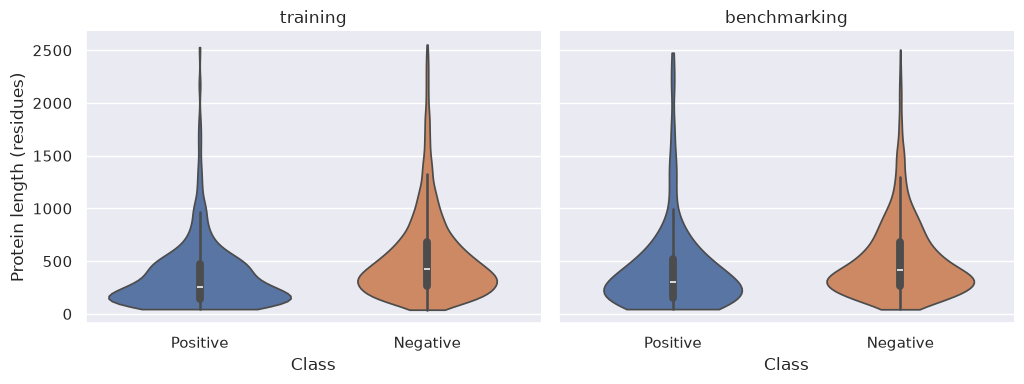

In [10]:
g = sns.catplot(
    data=protein_lengths_trimmed, x="protein_class", y="length",
    order=class_order, hue="protein_class",
    hue_order=class_order, palette=class_palette, legend=False,
    col="split", col_order=split_order,
    kind="violin", cut=0, inner="box",
    density_norm="area", common_norm=True,
    height=4, aspect=1.3
)
g.set_axis_labels("Class", "Protein length (residues)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_1_4_protein_length_violin_p99.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_1_4_protein_length_violin_p99.pdf")
plt.show()


### 1.2 Signal-peptide lengths


#### 1.2.1 Full-range histogram

For positive proteins, `cleavage_pos` gives the SP length, as established in 02a. We use the same histogram method with one-residue intervals centred on integers and common edges across splits. Percentages are calculated independently within each split.


Plot saved in: ../results/figures/02c/1_2_1_sp_length_histogram_full.pdf


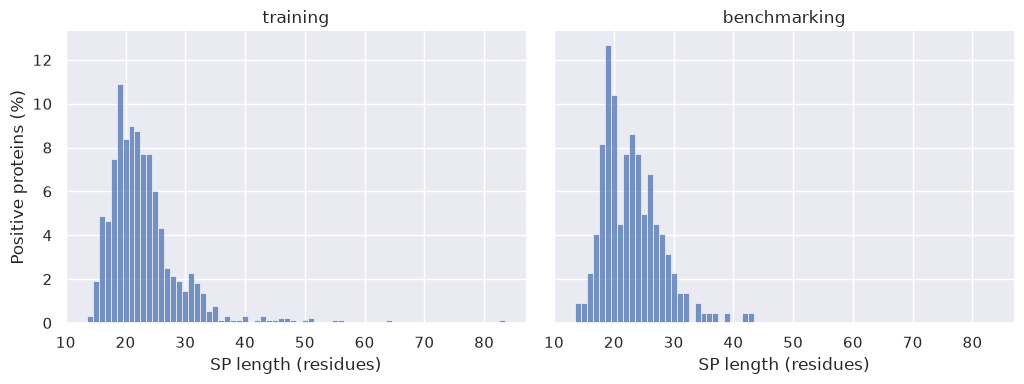

In [11]:
g = sns.displot(
    data=sp_lengths, x="cleavage_pos",
    col="split", col_order=split_order,
    kind="hist", bins=sp_bins,
    stat="percent", common_norm=False,
    color=class_palette["Positive"],
    height=4, aspect=1.3
)
g.set_axis_labels("SP length (residues)", "Positive proteins (%)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_2_1_sp_length_histogram_full.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_2_1_sp_length_histogram_full.pdf")
plt.show()


#### 1.2.2 Focus on the central SP-length range

We apply the same visualization approach as in section 1.1.2, using a separate cutoff: the 99th percentile of SP lengths in positive training proteins. We apply it unchanged to benchmarking and retain the full-range histogram above. The table reports exclusions; histogram percentages refer to retained positives within each split.


In [12]:
sp_length_cutoff = sp_lengths.loc[
    sp_lengths["split"] == "training", "cleavage_pos"
].quantile(0.99)

sp_lengths_trimmed = sp_lengths[
    sp_lengths["cleavage_pos"] <= sp_length_cutoff
]
trimmed_sp_bins = [
    position - 0.5
    for position in range(
        int(sp_lengths_trimmed["cleavage_pos"].min()),
        int(sp_length_cutoff) + 2
    )
]

print("SP-length cutoff (residues):", sp_length_cutoff)
sp_excluded_counts = (
    sp_lengths.assign(excluded=sp_lengths["cleavage_pos"] > sp_length_cutoff)
    .groupby("split")["excluded"]
    .agg(total="size", excluded="sum")
)
sp_excluded_counts


SP-length cutoff (residues): 47.0


,total,excluded
split,,
benchmarking,221,0
training,881,8


Plot saved in: ../results/figures/02c/1_2_2_sp_length_histogram_p99.pdf


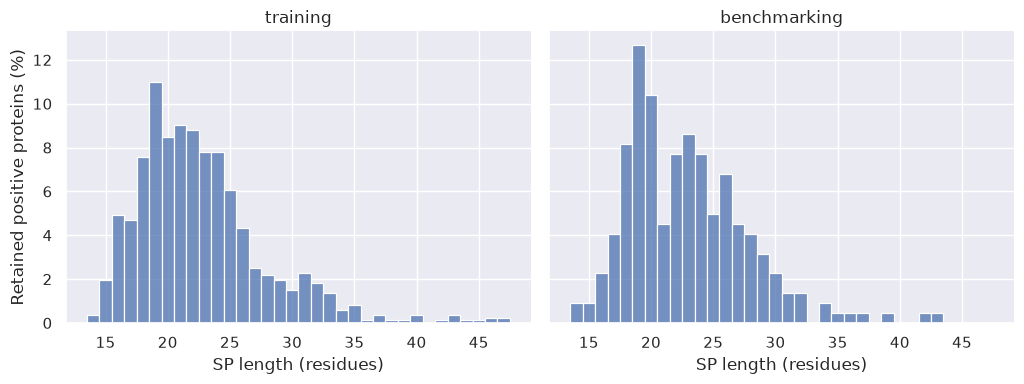

In [13]:
g = sns.displot(
    data=sp_lengths_trimmed, x="cleavage_pos",
    col="split", col_order=split_order,
    kind="hist", bins=trimmed_sp_bins,
    stat="percent", common_norm=False,
    color=class_palette["Positive"],
    height=4, aspect=1.3
)
g.set_axis_labels("SP length (residues)", "Retained positive proteins (%)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_2_2_sp_length_histogram_p99.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_2_2_sp_length_histogram_p99.pdf")
plt.show()


#### 1.2.3 Boxplot

We summarize SP lengths with the same boxplot convention used for full proteins, keeping training and benchmarking in separate panels.

We use the SP-length subset retained in section 1.2.2.


Plot saved in: ../results/figures/02c/1_2_3_sp_length_boxplot_p99.pdf


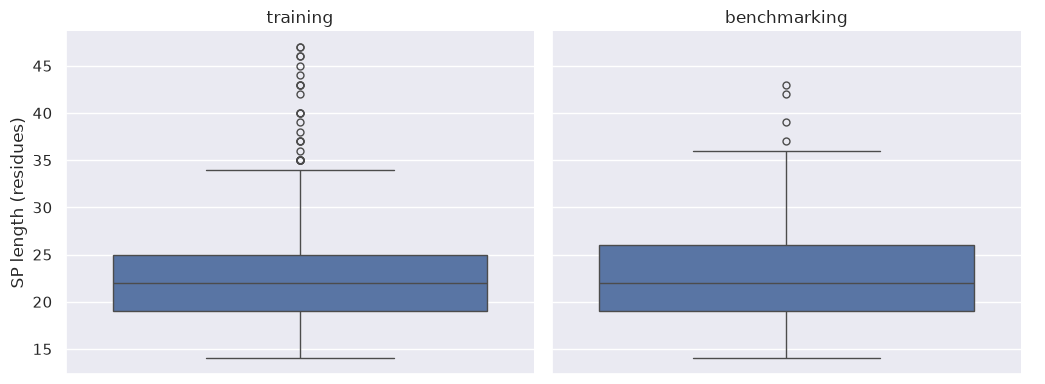

In [14]:
g = sns.catplot(
    data=sp_lengths_trimmed, y="cleavage_pos",
    col="split", col_order=split_order,
    kind="box", color=class_palette["Positive"],
    height=4, aspect=1.3
)
g.set_axis_labels("", "SP length (residues)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_2_3_sp_length_boxplot_p99.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_2_3_sp_length_boxplot_p99.pdf")
plt.show()


#### 1.2.4 Violin plot

We use the same violin settings for SP lengths. The smooth outline approximates a distribution of integer lengths; its width does not represent the number of proteins in the split. We compare these views before choosing which figures to retain.

We use the SP-length subset retained in section 1.2.2.


Plot saved in: ../results/figures/02c/1_2_4_sp_length_violin_p99.pdf


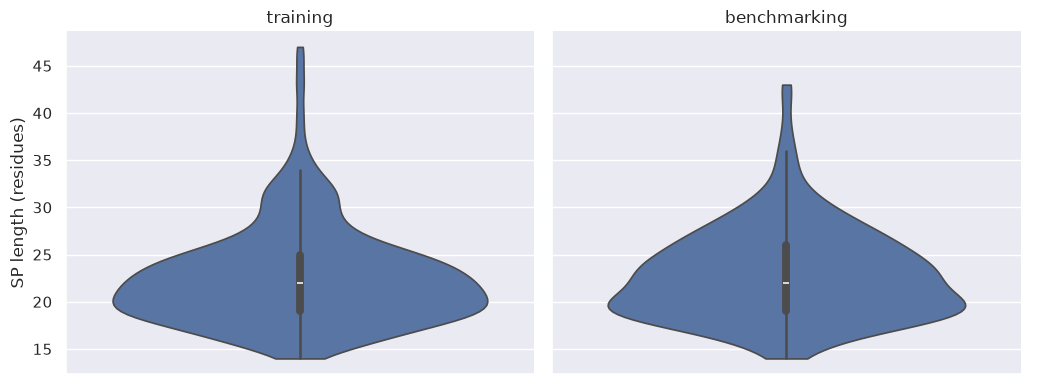

In [15]:
g = sns.catplot(
    data=sp_lengths_trimmed, y="cleavage_pos",
    col="split", col_order=split_order,
    kind="violin", color=class_palette["Positive"],
    cut=0, inner="box", density_norm="area", common_norm=True,
    height=4, aspect=1.3
)
g.set_axis_labels("", "SP length (residues)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "1_2_4_sp_length_violin_p99.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "1_2_4_sp_length_violin_p99.pdf")
plt.show()


### 1.3 Observations

- **Protein lengths:** in both splits, retained positive proteins tend to be shorter than negatives. Their histograms concentrate more strongly at short lengths, and their boxplots show lower medians and narrower interquartile ranges. However, the distributions overlap substantially, so length alone does not clearly separate the classes.
- **SP lengths:** training and benchmarking show similar central distributions, with medians around 22 residues and most of the central half near 19–26 residues. Both have a right tail, although individual histogram peaks differ. This supports comparable SP-length distributions across the splits, rather than proving that they are balanced in every respect; class proportions and taxonomy are separate questions.
- **Effect of trimming:** these comparisons describe the retained subsets. The protein cutoff is approximately 2558 residues. The SP cutoff is 47 residues and excludes eight training proteins but no benchmarking proteins, so their upper tails are not identical. The full-range histograms preserve that context. These are descriptive observations, not a statistical test of equivalence.


## 2. Signal-peptide amino-acid composition

We compare SP composition with SwissProt separately for training and benchmarking, using grouped bars as requested in 02c slides 6 and 12. We follow the `catplot(kind="bar")` example in the Categorical plots section of `Plotting in Seaborn.pdf`.

We use all positive proteins: the P99 cutoffs in step 1 were only used to display length distributions. SwissProt provides a general protein background, not the composition of our negative class or an exclusively eukaryotic reference.


### 2.1 Extract the signal peptides

As established in 02a, `cleavage_pos` is the last residue of the SP, starting at position 1. The slice `sequence[:cleavage_pos]` therefore retains the complete SP and excludes the mature protein.


In [16]:
sp_sequences = {}
for row in positive_metadata.itertuples(index=False):
    sp_sequences[row.accession] = positive_sequences[row.accession][:row.cleavage_pos]


### 2.2 SwissProt reference

We retain the published percentages from [SwissProt release statistics, section 6.1](https://web.expasy.org/docs/relnotes/relstat.html), release **2026_03 (2 September 2026)**, consulted on **24 September 2026**. The values below are a fixed copy of that table, so later website updates do not change this comparison.

We normalize these rounded percentages over the 20 canonical amino acids to match the denominator used for SPs.


In [17]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
swissprot_percent = {
    "A": 8.25, "C": 1.38, "D": 5.46, "E": 6.71, "F": 3.86,
    "G": 7.07, "H": 2.27, "I": 5.90, "K": 5.79, "L": 9.64,
    "M": 2.41, "N": 4.06, "P": 4.75, "Q": 3.93, "R": 5.52,
    "S": 6.66, "T": 5.36, "V": 6.85, "W": 1.10, "Y": 2.92,
}
swissprot_total = sum(swissprot_percent.values())


### 2.3 Count residues and compare compositions

We pool SP residues within each split and calculate each amino acid's percentage among known canonical residues. Each residue contributes equally, so longer SPs contribute more residues; this is a residue composition rather than an average of per-protein percentages.

Unknown residues (`X`) are excluded from the denominator, while the other residues of the same protein are retained. The summary reports all non-canonical residues excluded from counting, together with the number of SPs and counted residues.


In [18]:
composition_rows = []
residue_summary = []

for split in split_order:
    accessions = positive_metadata.loc[
        positive_metadata["split"] == split, "accession"
    ]
    residues = "".join(sp_sequences[accession] for accession in accessions)
    counts = {aa: residues.count(aa) for aa in amino_acids}
    known_residues = sum(counts.values())

    residue_summary.append({
        "split": split,
        "SPs": len(accessions),
        "Canonical residues": known_residues,
        "Excluded non-canonical residues": len(residues) - known_residues,
    })

    for aa in amino_acids:
        composition_rows.append({
            "split": split, "amino_acid": aa, "source": "SP",
            "percentage": 100 * counts[aa] / known_residues,
        })
        composition_rows.append({
            "split": split, "amino_acid": aa, "source": "SwissProt",
            "percentage": 100 * swissprot_percent[aa] / swissprot_total,
        })

aa_composition = pd.DataFrame(composition_rows)
pd.DataFrame(residue_summary)


,split,SPs,Canonical residues,Excluded non-canonical residues
0,training,881,20225,11
1,benchmarking,221,5065,0


We use the same amino-acid order, colors and percentage scale in both panels. Each bar represents an aggregated composition, so we omit error bars. Differences from SwissProt describe enrichment or depletion relative to this general background; they do not directly measure differences between our positive and negative classes.


Plot saved in: ../results/figures/02c/2_3_sp_amino_acid_composition.pdf


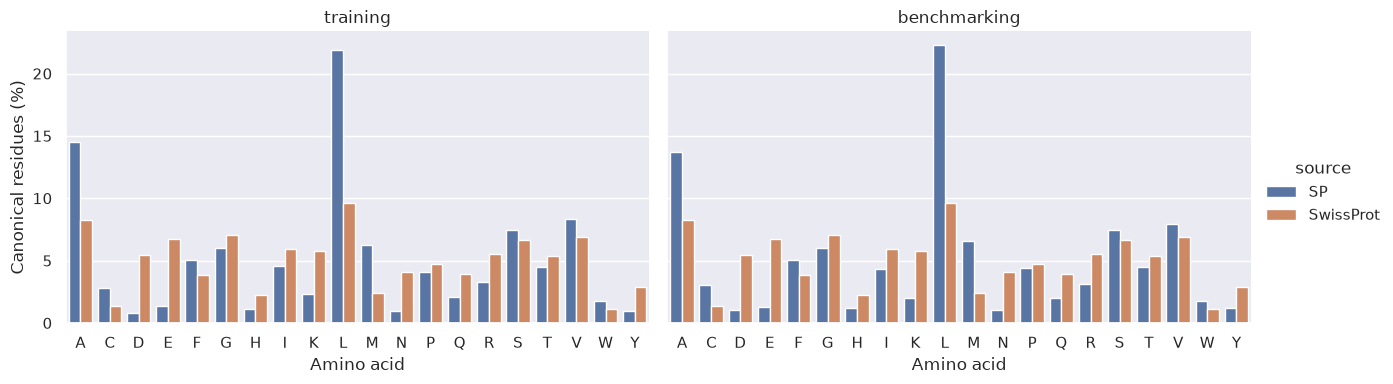

In [19]:
g = sns.catplot(
    data=aa_composition, x="amino_acid", y="percentage",
    order=amino_acids, hue="source", hue_order=["SP", "SwissProt"],
    palette={"SP": "C0", "SwissProt": "C1"},
    col="split", col_order=split_order,
    kind="bar", errorbar=None,
    height=4, aspect=1.6
)
g.set_axis_labels("Amino acid", "Canonical residues (%)")
g.set_titles("{col_name}")
g.savefig(figure_dir / "2_3_sp_amino_acid_composition.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "2_3_sp_amino_acid_composition.pdf")
plt.show()


### 2.4 Observations

In both training and benchmarking, signal peptides show higher proportions of alanine (A) and especially leucine (L) than the SwissProt background. Aspartate (D), histidine (H), asparagine (N) and glutamate (E) are less represented. Tyrosine (Y) also has a slightly lower proportion than in SwissProt.

The same broad pattern appears in both splits. These observations describe the SP regions of positive proteins relative to a general SwissProt background, rather than a comparison of complete positive and negative proteins. We have not tested the statistical significance of these differences.


## 3. Taxonomic composition

We describe kingdoms and species separately for training and benchmarking, as requested in 02c slides 6 and 12. Slides 9 and 12 allow barplots or pie charts; we prepare both before choosing the final figures. We follow the Categorical plots and Other plots sections of `Plotting in Seaborn.pdf`: `sns.catplot(kind="bar")` for bars and Matplotlib `pie` with pandas counts for pies.

All prepared proteins are included, without the length cutoffs from step 1. Percentages are calculated within each class and split, so differences in class size do not dominate the comparison.


In [20]:
taxonomy = pd.concat([
    positive_metadata[["kingdom", "organism", "split"]].assign(protein_class="Positive"),
    negative_metadata[["kingdom", "organism", "split"]].assign(protein_class="Negative"),
], ignore_index=True)


### 3.1 Kingdoms

We retain the categories assigned in 02a: Metazoa, Fungi, Viridiplantae and Other. Here, Other denotes the remaining taxonomic lineages. The barplots compare classes within each split; the four pies show their compositions separately, with fixed category colors and order.


In [21]:
kingdom_order = ["Metazoa", "Fungi", "Viridiplantae", "Other"]
kingdom_rows = []

for split in split_order:
    for protein_class in class_order:
        subset = taxonomy[
            (taxonomy["split"] == split)
            & (taxonomy["protein_class"] == protein_class)
        ]
        counts = subset["kingdom"].value_counts().reindex(kingdom_order, fill_value=0)
        for kingdom in kingdom_order:
            kingdom_rows.append({
                "split": split, "protein_class": protein_class,
                "kingdom": kingdom, "count": counts[kingdom],
                "percentage": 100 * counts[kingdom] / len(subset),
            })

kingdom_composition = pd.DataFrame(kingdom_rows)


#### 3.1.1 Barplots

Grouped bars use the class colors from the preceding comparisons. Each bar is an observed percentage, so we omit error bars and use the same 0–100% scale in both panels.


Plot saved in: ../results/figures/02c/3_1_1_kingdom_barplots.pdf


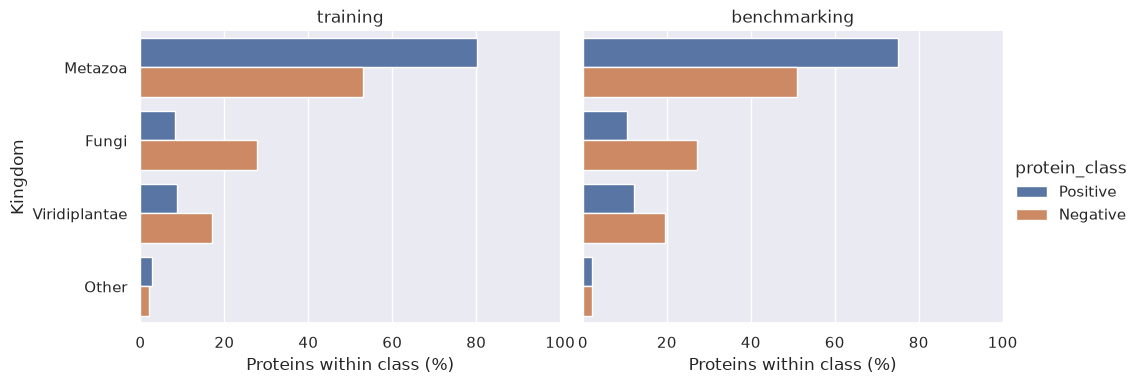

In [22]:
g = sns.catplot(
    data=kingdom_composition, x="percentage", y="kingdom",
    order=kingdom_order, hue="protein_class",
    hue_order=class_order, palette=class_palette,
    col="split", col_order=split_order,
    kind="bar", errorbar=None, height=4, aspect=1.3
)
g.set_axis_labels("Proteins within class (%)", "Kingdom")
g.set(xlim=(0, 100))
g.set_titles("{col_name}")
g.savefig(figure_dir / "3_1_1_kingdom_barplots.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "3_1_1_kingdom_barplots.pdf")
plt.show()


#### 3.1.2 Pie charts

The pies use the same counts as the bars. Colors identify kingdoms consistently across all four panels. Percent labels below 1% are omitted for readability; their slices remain included.


Plot saved in: ../results/figures/02c/3_1_2_kingdom_pie_charts.pdf


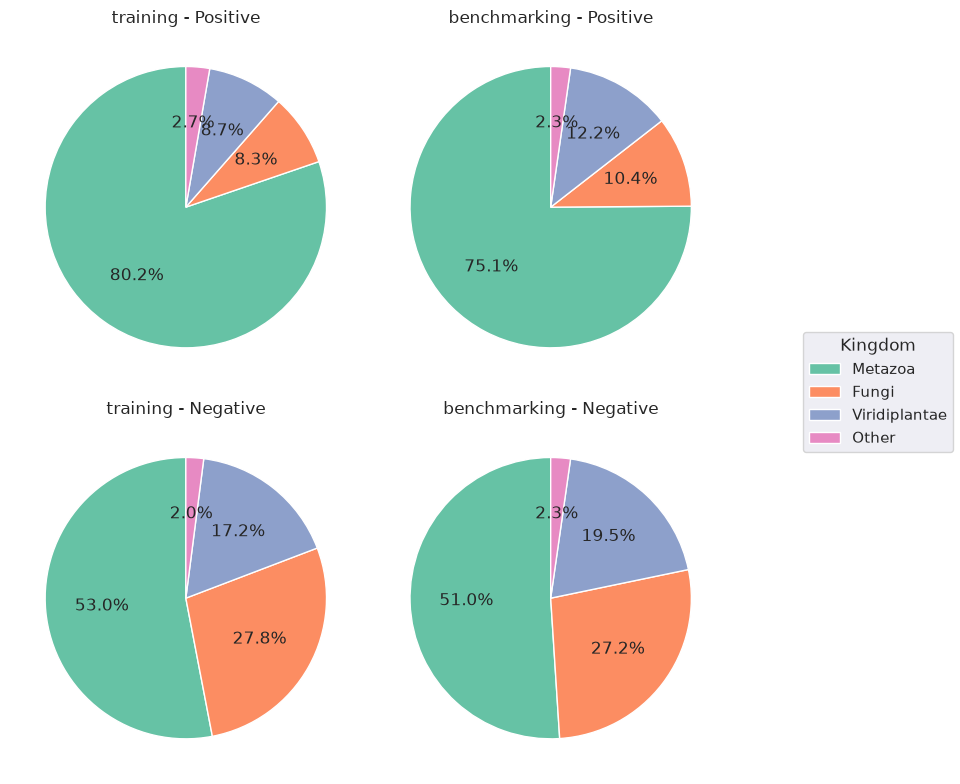

In [23]:
kingdom_colors = sns.color_palette("Set2", len(kingdom_order))
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, protein_class in enumerate(class_order):
    for j, split in enumerate(split_order):
        counts = kingdom_composition[
            (kingdom_composition["split"] == split)
            & (kingdom_composition["protein_class"] == protein_class)
        ].set_index("kingdom")["count"].reindex(kingdom_order)
        wedges, _, _ = axes[i, j].pie(
            counts, colors=kingdom_colors, startangle=90,
            autopct=lambda percentage: f"{percentage:.1f}%" if percentage >= 1 else ""
        )
        axes[i, j].set_title(f"{split} - {protein_class}")

fig.legend(wedges, kingdom_order, loc="center right", title="Kingdom")
fig.tight_layout(rect=(0, 0, 0.82, 1))
fig.savefig(figure_dir / "3_1_2_kingdom_pie_charts.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "3_1_2_kingdom_pie_charts.pdf")
plt.show()


### 3.2 Species

To keep the figures readable, we select the five most frequent species in each training class and take their union. This gives each class a say in the selection despite the larger negative set. We use the same species and order for benchmarking, grouping all remaining organisms as Other species. This category is a plotting group, distinct from the Other kingdom.

We keep complete species counts in `species_counts`. The five-per-class choice is ours, not a requirement of the slides; the percentages still use all proteins in each class and split.

The table below lists the five most frequent species within each training class, ordered by count. Percentages use all training proteins of that class as the denominator. A species can appear in both lists, but it enters the shared plotting selection only once.


In [24]:
species_counts = (
    taxonomy.groupby(["split", "protein_class", "organism"])
    .size()
    .reset_index(name="count")
)

selected_species = []
top_species_rows = []
for protein_class in class_order:
    training_species = taxonomy.loc[
        (taxonomy["split"] == "training")
        & (taxonomy["protein_class"] == protein_class), "organism"
    ]
    top_species = training_species.value_counts().head(5)
    for species, count in top_species.items():
        top_species_rows.append({
            "protein_class": protein_class,
            "species": species,
            "count": count,
            "percentage": 100 * count / len(training_species),
        })
        if species not in selected_species:
            selected_species.append(species)

top_training_species = pd.DataFrame(top_species_rows)
top_training_species


,protein_class,species,count,percentage
0,Positive,Homo sapiens,275,31.214529
1,Positive,Mus musculus,49,5.561862
2,Positive,Rattus norvegicus,42,4.767310
3,Positive,Bos taurus,39,4.426788
4,Positive,Sus scrofa,24,2.724177
5,Negative,Homo sapiens,1898,26.125258
6,Negative,Saccharomyces cerevisiae (strain ATCC 204508 /...,1266,17.426015
7,Negative,Arabidopsis thaliana,988,13.599449
8,Negative,Mus musculus,938,12.911218
9,Negative,Schizosaccharomyces pombe (strain 972 / ATCC 2...,557,7.666896


In [25]:
species_order = selected_species + ["Other species"]
taxonomy["species_group"] = taxonomy["organism"].where(
    taxonomy["organism"].isin(selected_species), "Other species"
)

species_rows = []
for split in split_order:
    for protein_class in class_order:
        subset = taxonomy[
            (taxonomy["split"] == split)
            & (taxonomy["protein_class"] == protein_class)
        ]
        counts = subset["species_group"].value_counts().reindex(species_order, fill_value=0)
        for species in species_order:
            species_rows.append({
                "split": split, "protein_class": protein_class,
                "species": species, "count": counts[species],
                "percentage": 100 * counts[species] / len(subset),
            })

species_composition = pd.DataFrame(species_rows)


#### 3.2.1 Barplots

Horizontal bars leave space for species names. We keep the same class colors, category order and percentage scale across splits.


Plot saved in: ../results/figures/02c/3_2_1_species_barplots.pdf


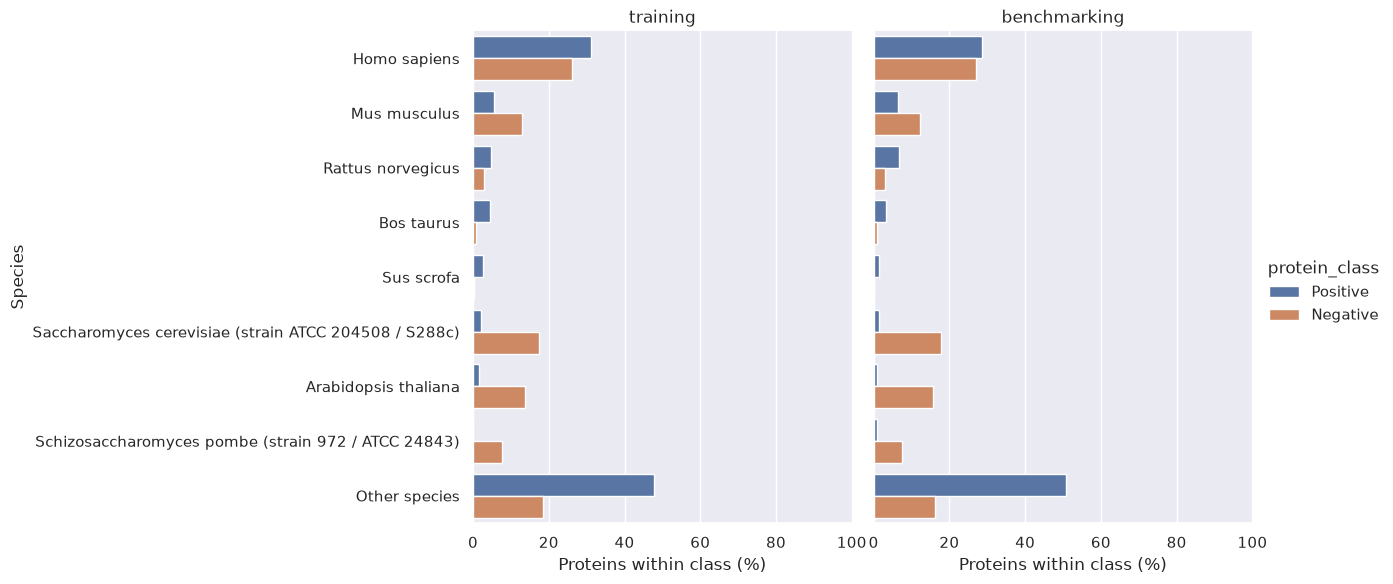

In [26]:
g = sns.catplot(
    data=species_composition, x="percentage", y="species",
    order=species_order, hue="protein_class",
    hue_order=class_order, palette=class_palette,
    col="split", col_order=split_order,
    kind="bar", errorbar=None, height=6, aspect=1.1
)
g.set_axis_labels("Proteins within class (%)", "Species")
g.set(xlim=(0, 100))
g.set_titles("{col_name}")
g.savefig(figure_dir / "3_2_1_species_barplots.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "3_2_1_species_barplots.pdf")
plt.show()


#### 3.2.2 Pie charts

We use the same grouped counts as the species bars. A shared legend avoids placing long species names around the slices; category colors and order remain fixed across panels. Other species is grey.


Plot saved in: ../results/figures/02c/3_2_2_species_pie_charts.pdf


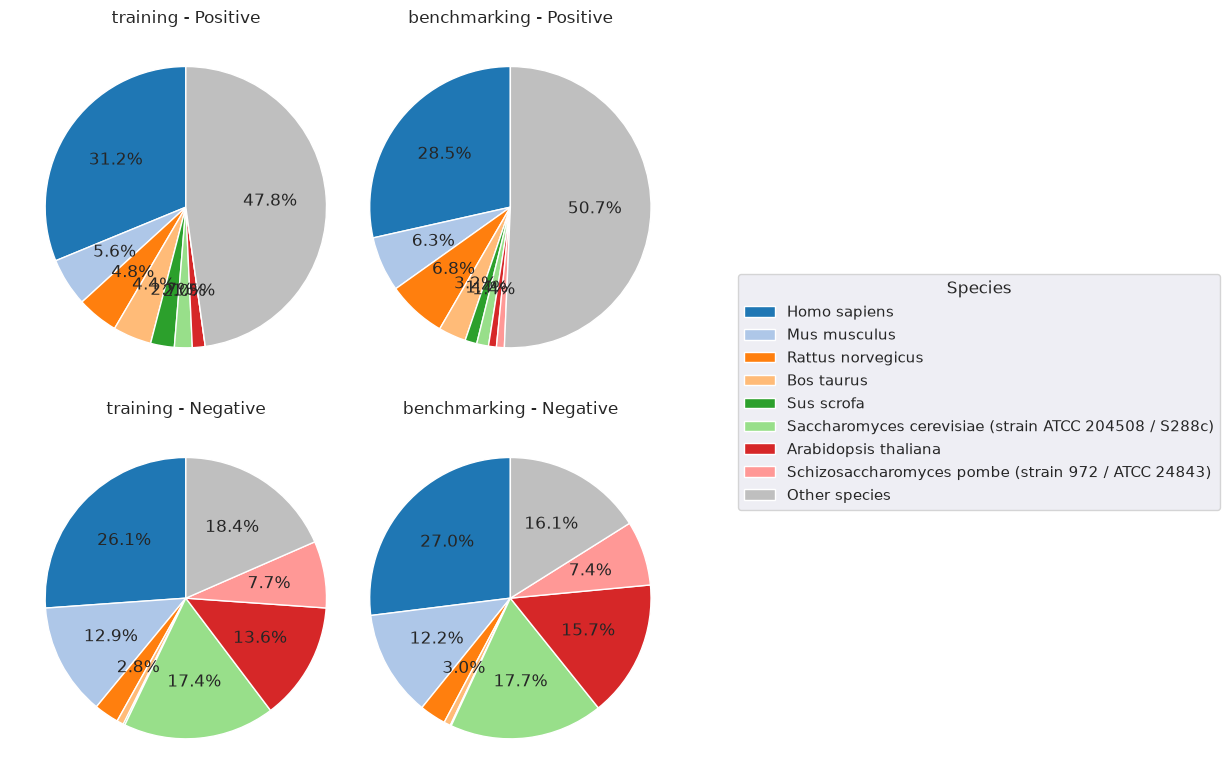

In [27]:
species_colors = sns.color_palette("tab20", len(selected_species)) + [(0.75, 0.75, 0.75)]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, protein_class in enumerate(class_order):
    for j, split in enumerate(split_order):
        counts = species_composition[
            (species_composition["split"] == split)
            & (species_composition["protein_class"] == protein_class)
        ].set_index("species")["count"].reindex(species_order)
        wedges, _, _ = axes[i, j].pie(
            counts, colors=species_colors, startangle=90,
            autopct=lambda percentage: f"{percentage:.1f}%" if percentage >= 1 else ""
        )
        axes[i, j].set_title(f"{split} - {protein_class}")

fig.legend(wedges, species_order, loc="center right", title="Species")
fig.tight_layout(rect=(0, 0, 0.65, 1))
fig.savefig(figure_dir / "3_2_2_species_pie_charts.pdf", format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_dir / "3_2_2_species_pie_charts.pdf")
plt.show()


### 3.3 Observations

Metazoa is more strongly represented among positives than negatives: 80.2% versus 53.0% in training and 75.1% versus 51.0% in benchmarking. Negatives include larger proportions of Fungi and Viridiplantae. The pattern is consistent across splits, although the percentages are not identical. This indicates a difference in taxonomic composition between the classes that should be considered when interpreting later comparisons.

The selected species cover a smaller fraction of positives: Other species accounts for 47.8% of training positives and 50.7% of benchmarking positives, compared with 18.4% and 16.1% of negatives. Thus, more positive proteins fall outside the displayed species set. Because Other species pools multiple organisms, its size alone does not establish greater species richness or diversity. A strong Metazoa predominance is compatible with proteins being distributed across many animal species.

The species bars make the smaller categories easier to compare than the pies, where several labels overlap. We retain the current species selection and show the five most frequent species in each training class in the table above, making the basis of the grouping explicit.


## 4. Cleavage-site sequence logos

Following 02c slides 10–12, we align the regions from 13 residues before to two residues after the annotated SP cleavage site and build a WebLogo for each split. We use all positive proteins, without the visualization cutoffs from step 1. These are fixed windows aligned by the known cleavage site, not a multiple-sequence alignment search.

WebLogo generates the sequence logos locally. As in Showing and saving figures from the Seaborn support, we save numbered PDFs and display each figure in the notebook; Seaborn itself does not generate the logos.


### 4.1 Local setup

We use WebLogo locally to construct the logos and Ghostscript to render PDF files and PNG previews ([WebLogo manual](https://weblogo.threeplusone.com/manual.html)). Uncomment and run the installation command once in the LB2 kernel, then comment it again. Skip installation if these packages are already available.

We pin WebLogo 3.7.12 because the rendering adjustment in section 4.3 targets its PostScript template. Setuptools 80.9.0 provides the `pkg_resources` API required by this version of WebLogo. Its deprecation warning does not prevent logo generation.

If the kernel is restarted after installation, rerun step 0 and the cell defining `split_order` in step 1 before continuing here. No `GS_OPTIONS` setting is required.


In [28]:
# %conda install -c conda-forge weblogo=3.7.12 ghostscript setuptools=80.9.0 -y


We call WebLogo and Ghostscript from Python. The following cell imports the tools needed to run these commands and display the logos, and creates the directory for the cleavage-window FASTA files.


In [29]:
import subprocess
from IPython.display import Image, display

window_dir = Path("../data/analysis")
window_dir.mkdir(parents=True, exist_ok=True)


### 4.2 Extract and save cleavage windows

For an annotated cleavage position `c`, the slice `sequence[c-13:c+2]` contains 15 residues: positions −13…−1 from the SP and +1,+2 from the mature protein. We retain accession identifiers and save one FASTA file per split.

Unknown residues such as `X` stay in the FASTA to preserve alignment. WebLogo will ignore them when counting the 20 canonical amino acids at each position, rather than removing the protein or shifting its residues.


In [30]:
for split in split_order:
    metadata = positive_metadata[positive_metadata["split"] == split]
    fasta_path = window_dir / f"{split}_cleavage_sites.fasta"
    with open(fasta_path, "w", encoding="utf-8") as fasta_out:
        for row in metadata.itertuples(index=False):
            c = row.cleavage_pos
            window = positive_sequences[row.accession][c - 13:c + 2]
            print(f">{row.accession}", window, sep="\n", file=fasta_out)

    print("Cleavage windows:", len(metadata))
    print("FASTA saved in:", fasta_path)


Cleavage windows: 881
FASTA saved in: ../data/analysis/training_cleavage_sites.fasta
Cleavage windows: 221
FASTA saved in: ../data/analysis/benchmarking_cleavage_sites.fasta


### 4.3 Generate and save the logos

Following 02c slides 10–12, we compare conservation around the cleavage site in training and benchmarking. Both logos use the same 20-amino-acid alphabet, chemical-property colors and 0–2.5-bit axis. With composition adjustment disabled, stack height measures conservation relative to equal amino-acid frequencies (maximum approximately 4.32 bits); each letter's share of the stack reflects its frequency at that position. We omit error bars and use no background prior or small-sample correction, so the smaller benchmarking set may show more sampling variation.

Position labels skip zero: cleavage lies between −1 and +1. Stack widths reflect the number of counted residues at each position; unknown residues are not counted. These shared display settings make the two splits easier to compare.

WebLogo first produces EPS in memory. We remove its second letter-size refinement, which caused Ghostscript to fail on very small letters, and then render the PDF and PNG from the same EPS. This is a rendering workaround; sequence counts and information-content calculations are unchanged.

As in the Seaborn support's figure-saving examples, we save numbered PDFs and print their paths. The PNGs are displayed inline without saving additional image files; WebLogo, rather than Seaborn, constructs these logos.

We widen the stacks to separate position labels and use a shared 2.5-bit upper limit, above the peaks in both observed logos. This display range reduces empty space without changing the theoretical maximum of approximately 4.32 bits. Larger text and 300-dpi PNG previews improve readability; the saved PDFs remain vector graphics.


Plot saved in: ../results/figures/02c/4_3_training_cleavage_site_logo.pdf


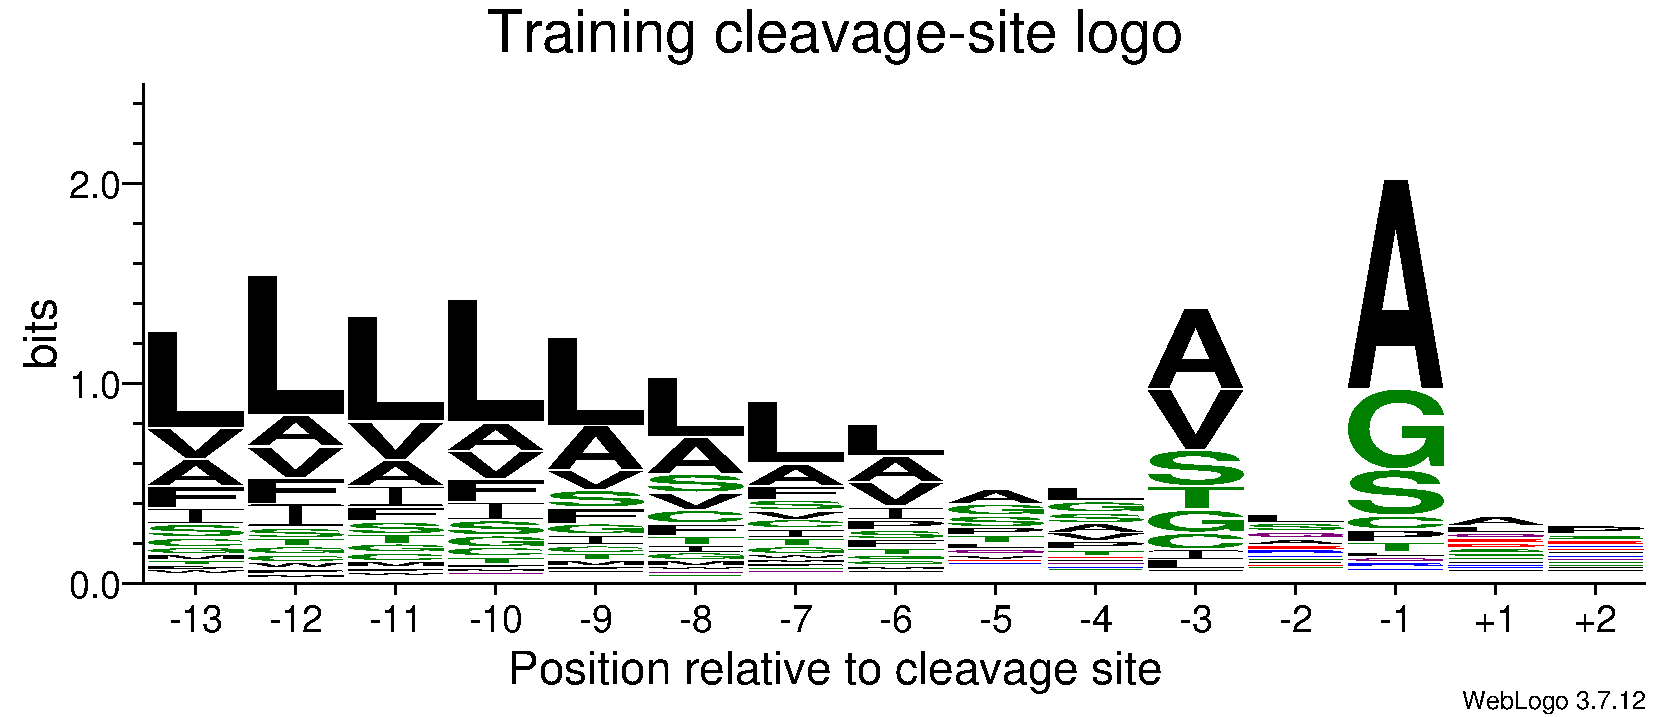

Plot saved in: ../results/figures/02c/4_3_benchmarking_cleavage_site_logo.pdf


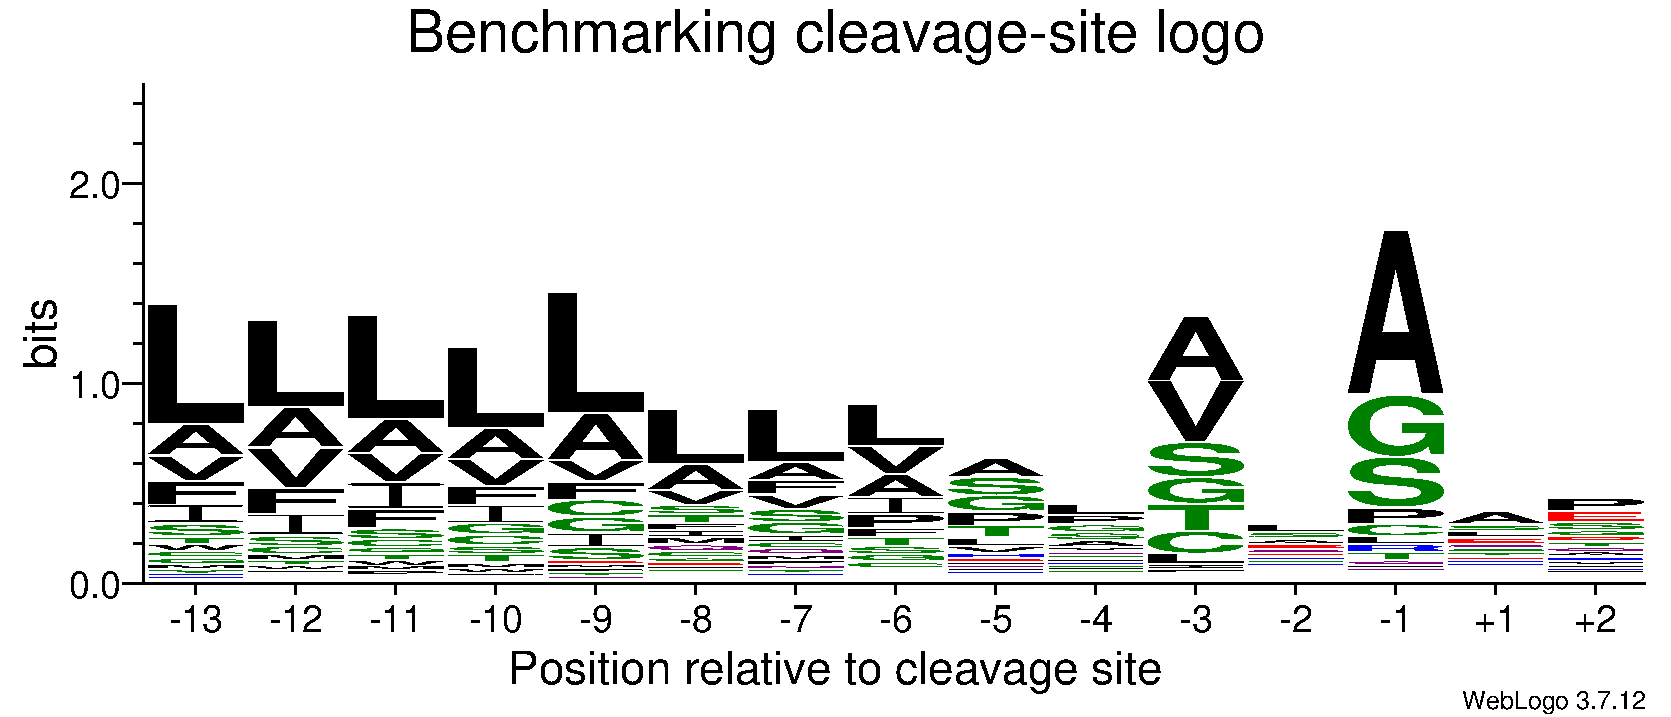

In [31]:
position_labels = [str(position) for position in range(-13, 0)] + ["+1", "+2"]

for split in split_order:
    fasta_path = window_dir / f"{split}_cleavage_sites.fasta"
    pdf_path = figure_dir / f"4_3_{split}_cleavage_site_logo.pdf"
    command = [
        "weblogo",
        "--fin", str(fasta_path),
        "--datatype", "fasta",
        "--alphabet", "ACDEFGHIKLMNPQRSTVWY",
        "--units", "bits",
        "--composition", "none",
        "--errorbars", "NO",
        "--color-scheme", "chemistry",
        "--stacks-per-line", "15",
        "--annotate=" + ",".join(position_labels),
        "--number-interval", "1",
        "--yaxis", "2.5",
        "--ticmarks", "1",
        "--stack-width", "24",
        "--aspect-ratio", "5",
        "--fontsize", "11",
        "--number-fontsize", "9",
        "--title-fontsize", "14",
        "--title", split.capitalize() + " cleavage-site logo",
        "--xlabel", "Position relative to cleavage site",
        "--text-font", "Helvetica",
        "--title-font", "Helvetica",
        "--logo-font", "Helvetica-Bold",
    ]

    eps = subprocess.run(
        command + ["--format", "eps"], check=True, capture_output=True
    ).stdout.decode()
    # Avoid WebLogo's second font-scaling pass, which fails for tiny letters.
    eps = eps.replace("2 {\n            gsave", "1 {\n            gsave", 1)

    for device in ["pdfwrite", "png16m"]:
        rendered = subprocess.run(
            ["gs", "-q", "-dSAFER", "-dBATCH", "-dNOPAUSE", "-dEPSCrop",
             "-sDEVICE=" + device, "-r300", "-sOutputFile=-", "-"],
            input=eps.encode(), check=True, capture_output=True
        ).stdout
        if device == "pdfwrite":
            pdf_path.write_bytes(rendered)
            print("Plot saved in:", pdf_path)
        else:
            display(Image(data=rendered, width=800))
